# One-loop Z2SSM $\leftrightarrow$ SMEFT Matching

In [ ]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 600



# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.EFT_matching

import fit_utils.EFT_matching as EFT_matching

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pickle
vev = 246.
Mh = 125.

BP_input_dir = "."
BP_dicts_filename = f"{BP_input_dir}/Z2SSM_Benchmark_Points_outliers_dicts.pkl"

with open(BP_dicts_filename, 'rb') as f:
    BPs = pickle.load(f)
    bp_kappas = BPs["kappas"]
    # bp_EWPOs = BPs["EWPOs"]
    bp_model_pars = BPs["model_pars"]
    bp_indices = BPs["indices"]

print("BP kappas:", bp_kappas)
# print("BP EWPOs:", bp_EWPOs)
print("BP model parameters:", bp_model_pars)
print("BP indices:", bp_indices)

mS = np.array([bp["mS"] for bp in bp_model_pars]); print("\nmS [GeV]:", mS)
muS = np.array([bp["muS"] for bp in bp_model_pars]); print("\nmuS [GeV]:", muS)
lamS = np.array([bp["lamS"] for bp in bp_model_pars]); print("\nlamS:", lamS)
lamSH = np.array([bp["lamSH"] for bp in bp_model_pars]); print("\nlamSH:", lamSH)
bp_lambdas = np.array([bp["lam"] for bp in bp_kappas]); print("\nBP lambdas (2L):", bp_lambdas)
bp_lambdas_1L = np.array([bp["lam1L"] for bp in bp_kappas]); print("\nBP lambdas (1L):", bp_lambdas_1L)

# Testing the relation between mS, muS, lamSH
mS_test = np.sqrt(muS**2 + 0.5*lamSH*vev**2); print("\nmS test (from muS, lamSH):", mS_test)
mS_diff = mS - mS_test; print("\nmS - mS test:", mS_diff)

# Initialize the Z2SSM matching class
Z2SSM = EFT_matching.Z2SSM(muS=muS, lamS=lamS, lamSH=lamSH)

# Getting the matched Wilson coefficients at the NP scale
matched_WCs = Z2SSM.get_coefficients()
print("\nMatched Wilson coefficients at lamNP = muS:")
for wc_name, wc_values in matched_WCs.items():
    print(f"{wc_name}: {wc_values}")

matched_kappa_lambdas = Z2SSM.get_kappa_lambda_SMEFT_match()
print("\nMatched SMEFT kappa_lambda at lamNP = muS:\n", matched_kappa_lambdas)
print("\nModel kappa_lambda predictions: ", bp_lambdas)


# Sorting arrays according to their 2L kala Z2SSM prediction
sort_indices = np.argsort(bp_lambdas)

bp_lambdas = bp_lambdas[sort_indices]
bp_lambdas_1L = bp_lambdas_1L[sort_indices]
matched_kappa_lambdas = matched_kappa_lambdas[sort_indices]
mS = mS[sort_indices]
muS = muS[sort_indices]
lamS = lamS[sort_indices]
lamSH = lamSH[sort_indices]
CH    = matched_WCs["CH"]    [sort_indices]
CHbox = matched_WCs["CHbox"] [sort_indices]

BP kappas: [{'lam': 1.0643594459030925, 'kappaSingleHiggs': 0.997795157109014, 'lam1L': 1.0163047292403735, 'uu': 0.997795157109014, 'dd': 0.997795157109014, 'ss': 0.997795157109014, 'cc': 0.997795157109014, 'bb': 0.997795157109014, 'tt': 0.997795157109014, 'ee': 0.997795157109014, 'mumu': 0.997795157109014, 'tautau': 0.997795157109014, 'ZZ': 0.997795157109014, 'WW': 0.997795157109014, 'gamgam': 0.997795157109014, 'Zgam': 0.997795157109014, 'gg': 0.997795157109014, 'ZZ_0': 0.9980563471636651, 'ZZ_0_with_WFR': 0.9979539099793131, 'ZZ_0_no_BSM': 1.0002630443516598, 'ZZ_0_with_WFR_no_BSM': 1.0001608331788296, 'ZZ_240': 0.9983849781927755, 'ZZ_240_with_WFR': 0.9982825747303763, 'ZZ_240_no_BSM': 1.0005909506201627, 'ZZ_240_with_WFR_no_BSM': 1.000488772946644, 'ZZ_240_use_HEPfit_C1_values': 0.9983408359865786, 'ZZ_240_with_WFR_HEPfit_C1_values': 0.9982384279958877, 'ZZ_365': 0.9980039274452023, 'ZZ_365_with_WFR': 0.9979014848798298, 'ZZ_365_no_BSM': 1.0002107402832767, 'ZZ_365_with_WFR_no_BS

### $\kappa_\lambda$

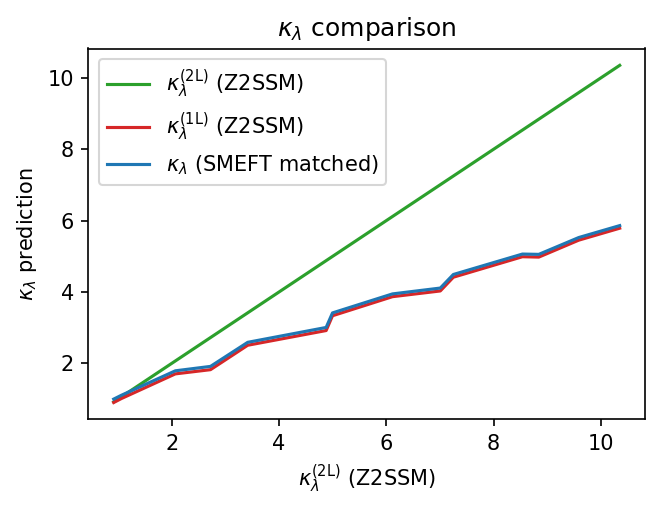

In [10]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, bp_lambdas, color='tab:green', label=r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, bp_lambdas_1L, color='tab:red', label=r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, matched_kappa_lambdas, color='tab:blue', label=r'$\kappa_{\lambda}$ (SMEFT matched)')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'$\kappa_{\lambda}$ prediction')
ax.set_title(r'$\kappa_{\lambda}$ comparison')
ax.legend()
plt.tight_layout()

# plot_dir = "./comparison_plots/matching_comparison"
# subprocess.run(["mkdir", "-p", plot_dir])
# plt.savefig(f"{plot_dir}/kappa_lambda_matching_comparison.pdf")

### $\kappa_\lambda$ (Zoomed-in version)

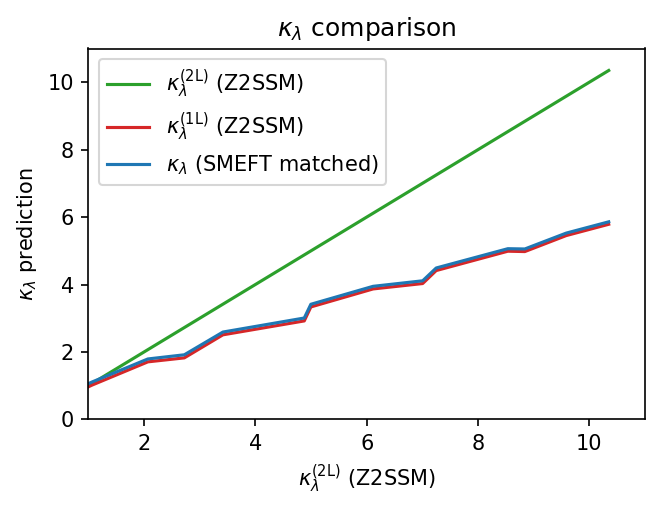

In [11]:
ax.set_xlim(1,11)
ax.set_ylim(0,11)
# fig.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_zoom.pdf")
fig

# Note: now, using lambdaNP=muS in the denominators, there is no need for this zoomed-in plot

### Wilson coefficients

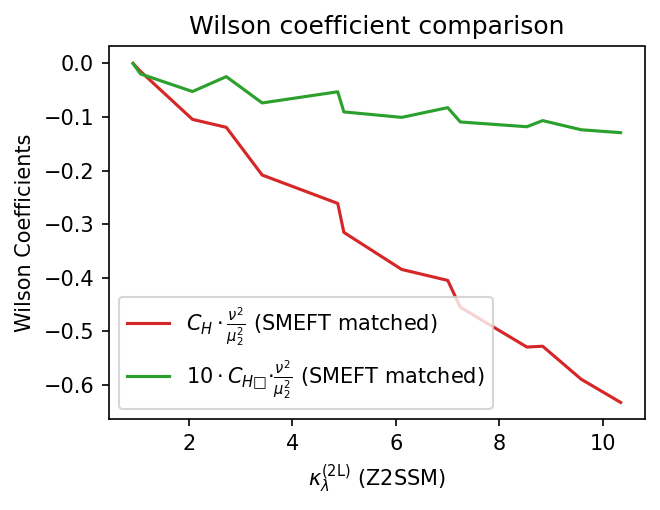

In [12]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, CH*vev**2, color='tab:red', label=r'$C_{H}\cdot \frac{\nu^2}{\mu_{2}^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 10*CHbox*vev**2, color='tab:green', label='$10\cdot C_{H\u25A1}$'+r'$\cdot \frac{\nu^2}{\mu_{2}^{2}}$ (SMEFT matched)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Wilson Coefficients')
ax.set_title(r'Wilson coefficient comparison')

ax.legend()
plt.tight_layout()

# plot_dir = "./comparison_plots/matching_comparison"
# subprocess.run(["mkdir", "-p", plot_dir])
# plt.savefig(f"{plot_dir}/WCs_matching_comparison.pdf")

### Model parameters

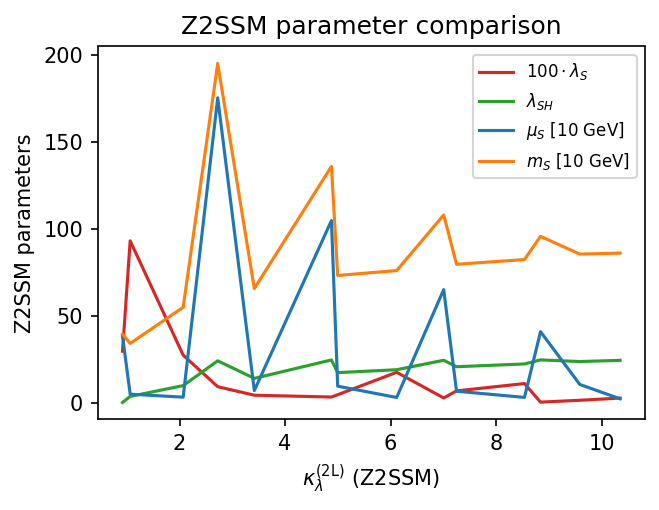

In [13]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, 100*lamS, color='tab:red', label=r'$100\cdot\lambda_{S}$')
ax.plot(bp_lambdas, lamSH, color='tab:green', label=r'$\lambda_{SH}$')
ax.plot(bp_lambdas, muS/10., color='tab:blue', label=r'$\mu_{S}$ [10 GeV]')
ax.plot(bp_lambdas, mS/10., color='tab:orange', label=r'$m_{S}$ [10 GeV]')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Z2SSM parameters')
ax.set_title(r'Z2SSM parameter comparison')
ax.legend(fontsize=8)
plt.tight_layout()

# plt.savefig(f"{plot_dir}/Z2SSM_parameters_matching_comparison.pdf")